Style Transfer According to Gatys et al. (2016)

[Paper Link](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
import matplotlib.pyplot as plt
import time
import os
from tqdm import tqdm
from scipy.optimize import fmin_l_bfgs_b

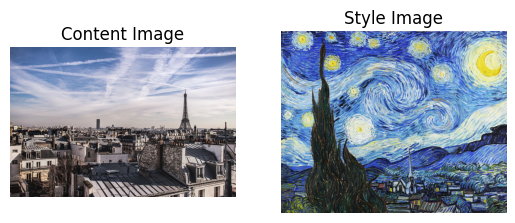

In [3]:
# Global constants
CONTENT_WEIGHT = 8e-4
STYLE_WEIGHT = 1
VAR_WEIGHT = 1e-5
MAX_DIM = 256  # Reduced image size to avoid memory issues
ITERATIONS = 100000

# Define content and style layers according to the paper
CONTENT_LAYER = 'block4_conv2'
STYLE_LAYERS = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

path_to_proj = "/content/drive/MyDrive/Master's/Second Year Grad/CV/CV Final Project"
content_img = "images/paris.jpg"
style_img = "vangogh/starry_night.jpg"

save_dir = os.path.join(path_to_proj, 'code/Final_Implementations/results')

content_path = os.path.join(path_to_proj, 'code/dataset', content_img)
style_path = os.path.join(path_to_proj, 'code/dataset', style_img)

# making save_dir if needed
os.makedirs(save_dir, exist_ok=True)

# showing initial images
fig, axs = plt.subplots(1, 2)

axs[0].set_title('Content Image')
axs[1].set_title('Style Image')

axs[0].axis('off')
axs[1].axis('off')
axs[0].imshow(plt.imread(content_path))
axs[1].imshow(plt.imread(style_path))
plt.show()

Load in images

In [4]:
def load_and_process_image(path, max_dim=MAX_DIM):
    """Load and preprocess an image for VGG19 with smaller dimensions."""
    img = load_img(path)

    # Resize image while preserving aspect ratio
    long_dim = max(img.size)
    scale = max_dim / long_dim
    new_size = tuple([int(dim * scale) for dim in img.size])
    img = img.resize(new_size)

    # Convert to array and add batch dimension
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for VGG19
    img_array = preprocess_input(img_array)

    return img_array

In [5]:
def deprocess_image(processed_img):
    """Convert processed image back to displayable format."""
    x = processed_img.copy()

    # Remove batch dimension
    if len(x.shape) == 4:
        x = np.squeeze(x, axis=0)

    # Undo VGG preprocessing
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]  # Convert BGR to RGB

    # Clip to valid range
    x = np.clip(x, 0, 255).astype('uint8')

    return x

In [6]:
content_image = load_and_process_image(content_path)
style_image = load_and_process_image(style_path)

Defining loss and helper functions

In [7]:
def gram_matrix(input_tensor):
    """Memory-efficient implementation of Gram matrix calculation."""
    # Ensure we're working with float32
    input_tensor = tf.cast(input_tensor, tf.float32)

    # Get dimensions
    shape = tf.shape(input_tensor)
    batch_size, height, width, num_filters = shape[0], shape[1], shape[2], shape[3]

    # Reshape the tensor: [batch_size, (height * width), num_filters]
    features = tf.reshape(input_tensor, (batch_size, height * width, num_filters))

    # Calculate gram matrix with batched matmul for better memory efficiency
    # G = F * F^T
    gram = tf.matmul(features, features, transpose_a=True)

    # Normalize by dividing by the number of locations (height * width)
    #gram = gram / tf.cast(height * width, tf.float32)

    return gram

In [8]:
@tf.function
def compute_content_loss(content_features, target_features):
    """Compute content loss as per the paper."""
    return (1/2) * tf.reduce_sum(tf.square(content_features - target_features))

In [9]:
@tf.function
def compute_style_layer_loss(style_features, target_features):
    """Compute style loss as per the paper."""
    target_gram = gram_matrix(target_features)
    style_gram = gram_matrix(style_features)

    N_l, M_l = target_features.shape[-1], target_features.shape[1]*target_features.shape[2]
    M_l = np.max([M_l, 1e-9]) # making sure it's not zero
    E_l = 1/(4*(N_l**2)*(M_l**2)) * tf.reduce_sum(tf.square(style_gram - target_gram))

    return E_l

In [10]:
@tf.function
def compute_loss(model, image, content_features, style_features):
    """Compute the total loss."""
    with tf.GradientTape() as tape:
        tape.watch(image)

        # Get features of current image
        x_features = model(image)

        # Content loss
        content_loss = compute_content_loss(content_features[CONTENT_LAYER], x_features[CONTENT_LAYER])

        # Style loss
        style_loss = tf.add_n([
            compute_style_layer_loss(style_features[name], x_features[name])
            for name in STYLE_LAYERS
        ])
        style_loss *= float(1/len(STYLE_LAYERS))

        # variation loss
        var_loss = tf.reduce_sum(tf.image.total_variation(image))

        # Total loss
        total_loss = (CONTENT_WEIGHT * content_loss) + (STYLE_WEIGHT * style_loss) + (VAR_WEIGHT * var_loss)

    # Get gradients
    grads = tape.gradient(total_loss, image)

    return total_loss, grads

In [11]:
def get_feature_representations(model, content_image, style_image):
    """Extract content and style features."""

    # Get feature representations
    content_outputs = model(content_image)
    style_outputs = model(style_image)

    # Extract content and style features
    content_features = {CONTENT_LAYER: content_outputs[CONTENT_LAYER]}

    # Pre-compute gram matrices for style layers to save memory
    style_features = {layer_name: value
                     for layer_name, value in style_outputs.items()
                     if layer_name in STYLE_LAYERS}

    return content_features, style_features

Loading in Model and altering it:
- Normalizing Model ([reference](https://github.com/corleypc/vgg-normalize/tree/master))
- Changing to average pooling from max pooling default

In [12]:
def normalize_vgg(model, N=5000, batch_size=4):
    # normalize model over ImageNet dataset

    print('Loading in Normalization Data...')
    dataset = tfds.load('imagenet_v2', split='test', shuffle_files=True)
    dataset = dataset.take(N).map(lambda x: tf.image.resize_with_crop_or_pad(x['image'],
                                                                             *content_image.shape[1:3]))
    dataset = dataset.batch(batch_size).prefetch(buffer_size=2)

    conv_outputs = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

    # model that returns activations from each conv layer
    activation_model = tf.keras.Model(inputs=model.input, outputs=conv_outputs)

    def layer_mean_activations(batch):
        """Filter activations averaged across positions and images in the batch"""
        activations = activation_model(batch)
        if not isinstance(activations, list):
            activations = [activations]
        return [tf.reduce_mean(act, axis=[0, 1, 2]) for act in activations]

    print('Gathering Mean Activations...')
    iters = N // batch_size
    accumulated_means = None
    for batch in tqdm(dataset):
        images = tf.cast(batch, tf.float32)
        images = preprocess_input(images)

        batch_means = layer_mean_activations(images)
        if accumulated_means is None:
            accumulated_means = batch_means
        else:
            for accumulated, m in zip(accumulated_means, batch_means):
                accumulated += m

    for accumulated in accumulated_means:
        accumulated /= iters

    print('Normalizing Mean Activations...')
    means_iter = iter(accumulated_means)
    prev_conv_layer_means = None
    for layer in tqdm(model.layers[1:]):
        if isinstance(layer, tf.keras.layers.Conv2D):
            means = next(means_iter)
            means = means.numpy()

            W, b = layer.get_weights()

            assert W.shape[-1] == means.shape[0]
            # weights layout is: (dim1, dim2, in_channels, out_channels)
            if prev_conv_layer_means is not None:
                # undo upstream normalization to restore scale of incoming channels
                W *= prev_conv_layer_means[np.newaxis, np.newaxis, : , np.newaxis]
            # then normalize activations by rescaling both weights and biases
            b /= (means + 1e-9)
            W /= (means[np.newaxis, np.newaxis, np.newaxis, :] + 1e-9)
            layer.set_weights([W, b])
            prev_conv_layer_means = means

    return model

In [13]:
def get_model():
    """Create a model that outputs the intermediate layers."""
    # Load VGG19
    vgg = VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    # Normalize model
    vgg = normalize_vgg(vgg)

    # replace max pooling with average pooling
    output_dict = {}
    input_layer, *layers = vgg.layers
    x = input_layer.output
    output_dict[input_layer.name] = x

    for layer in layers:
        if isinstance(layer, keras.layers.MaxPooling2D):
            layer = keras.layers.AveragePooling2D(
                pool_size=layer.pool_size,
                strides=layer.strides,
                padding=layer.padding,
                data_format=layer.data_format,
                name=f"{layer.name}_avg"
            )

        x=layer(x)
        output_dict[layer.name] = x

    # Create model
    return tf.keras.Model(inputs=vgg.input, outputs=output_dict)

Performing Style Transfer

In [14]:
def run_style_transfer(content_path, style_path):
    """Run the style transfer algorithm."""
    print("Building model...")
    model = get_model()

    print("\nLoading images and extracting features...")
    content_features, style_features = get_feature_representations(
        model, content_image, style_image
    )

    # Initialize as random noise
    generated_image = tf.Variable(tf.random.normal(content_image.shape,
                      mean=0.0, stddev=1.0,
                      dtype=tf.float32))

    # Create optimizer
    optimizer = tf.optimizers.Adam(learning_rate=1e-3)

    # Optimize with Adam
    print(f"\nStarting optimization with Adam for {ITERATIONS} iterations...")
    start_time = time.time()

    best_loss = float('inf')
    best_img = None

    # Main optimization loop
    for i in range(ITERATIONS):
        print(f"Iteration {i+1}/{ITERATIONS}")
        iteration_start = time.time()

        # Optimization loop
        loss, grad = compute_loss(model, generated_image,
                                  content_features, style_features)

        # Apply gradients
        optimizer.apply_gradients([(grad, generated_image)])

        generated_image.assign(tf.clip_by_value(generated_image, clip_value_min=-128.0, clip_value_max=255.0))

        if loss < best_loss:
            best_loss = loss
            best_img = generated_image.numpy()

        print(f"Loss: {loss}")
        print(f"Time for iteration {i+1}: {time.time() - iteration_start:.2f}s")

    # Return the best result
    final_img = best_img if best_img is not None else generated_image
    final_img = deprocess_image(final_img)

    print(f"Total time: {time.time() - start_time:.2f}s")

    return final_img

In [15]:
gen_img = run_style_transfer(content_path, style_path)

Building model...
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loading in Normalization Data...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

...

Dataset imagenet_v2 downloaded and prepared to /root/tensorflow_datasets/imagenet_v2/matched-frequency/3.0.0. Subsequent calls will reuse this data.
Gathering Mean Activations...


100%|██████████| 1250/1250 [00:57<00:00, 21.73it/s]


Normalizing Mean Activations...


100%|██████████| 21/21 [00:00<00:00, 163.97it/s]


Streaming output truncated to the last 5000 lines.
Time for iteration 98334: 0.02s
Iteration 98335/100000
Loss: 38.288604736328125
Time for iteration 98335: 0.02s
Iteration 98336/100000
Loss: 38.288475036621094
Time for iteration 98336: 0.02s
Iteration 98337/100000
Loss: 38.28834533691406
Time for iteration 98337: 0.02s
Iteration 98338/100000
Loss: 38.2882194519043
Time for iteration 98338: 0.02s
Iteration 98339/100000
Loss: 38.288089752197266
Time for iteration 98339: 0.02s
Iteration 98340/100000
Loss: 38.28795623779297
Time for iteration 98340: 0.02s
Iteration 98341/100000
Loss: 38.28782653808594
Time for iteration 98341: 0.02s
Iteration 98342/100000
Loss: 38.287696838378906
Time for iteration 98342: 0.02s
Iteration 98343/100000
Loss: 38.287567138671875
Time for iteration 98343: 0.02s
Iteration 98344/100000
Loss: 38.28742980957031
Time for iteration 98344: 0.02s
Iteration 98345/100000
Loss: 38.28730392456055
Time for iteration 98345: 0.02s
Iteration 98346/100000
Loss: 38.287170410156

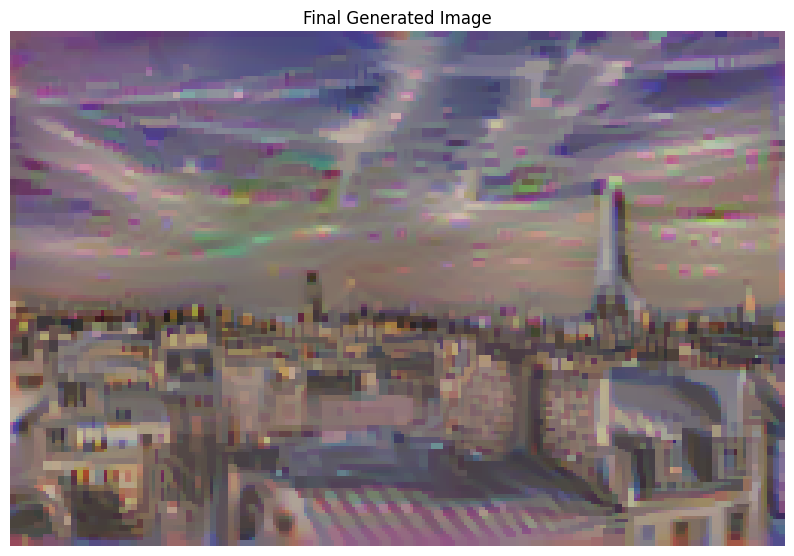

In [16]:
# Display result
plt.figure(figsize=(10, 10))
plt.title(f'Final Generated Image')
plt.imshow(gen_img)
plt.axis('off')
plt.show()

In [18]:
# Save result
content_name = content_img.split('/')[1].replace('.jpg', '')
style_name = style_img.split('/')[1].replace('.jpg', '')

save_path = os.path.join(save_dir, f"{content_name}_{style_name}_orig.jpg")
array_to_img(gen_img).save(save_path)
print(f"Style transfer complete! Image saved as '{content_name}_{style_name}_orig.jpg'")

Style transfer complete! Image saved as 'paris_starry_night_orig.jpg'
